<a href="https://colab.research.google.com/github/SunMingYang04/CV/blob/main/Modern_Computer_Vision_with_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第一部分 面向计算机视觉的深度学习基础知识

## 第一章 人工神经网络基础

### 前向传播

In [ ]:
#输入变量值（inputs），weights(如果是第一次迭代则随机初始化)和所提供数据集的实际outputs作为feed_forward的参数
import numpy as np
def feed_forward(inputs,outputs,weights):          #注意权重数组也包含了各节点的偏置项
  pre_hidden=np.dot(inputs,weights[0])+weights[1]      #连接输入层和隐藏层的权重值weights[0],weights[1]是与隐藏层有关的偏置
  hidden=1/(1+np.exp(-pre_hidden))             #对获得的隐藏层值使用sigmoid激活函数
  pred_out=np.dot(hidden,weights[2])+weights[3]       #同上得到输出层值
  mean_squared_error=np.mean(np.square(pred_out-outputs))
  return mean_squared_error

###反向传播

#### 梯度下降

In [2]:
import numpy as np
from copy import deepcopy
def feed_forward(inputs,outputs,weights):          #注意权重数组也包含了各节点的偏置项
  pre_hidden=np.dot(inputs,weights[0])+weights[1]      #连接输入层和隐藏层的权重值weights[0],weights[1]是与隐藏层有关的偏置
  hidden=1/(1+np.exp(-pre_hidden))             #对获得的隐藏层值使用sigmoid激活函数
  pred_out=np.dot(hidden,weights[2])+weights[3]       #同上得到输出层值
  mean_squared_error=np.mean(np.square(pred_out-outputs))
  return mean_squared_error
#2.权重与偏置增加一个很小的量，并更新计算总体误差损失的平方值
def update_weights(inputs,outputs,weights,lr):
  original_weights=deepcopy(weights)
  tmp_weights=deepcopy(weights)
  updated_weights=deepcopy(weights)
  original_loss=feed_forward(inputs,outputs,weights)
  for i,layer in enumerate(original_weights):
    for index,weight in np.ndenumerate(layer):
      tmp_weights=deepcopy(weights)
      tmp_weights[i][index]+=0.0001
      _loss_plus=feed_forward(inputs,outputs,tmp_weights)
      grad=(_loss_plus-original_loss)/0.0001
      updated_weights[i][index]-=lr*grad
  return updated_weights,original_loss

##常用链式法则，无需每次重新计算前向传播



###整合前向传播与反向传播

Text(0, 0.5, 'Loss value')

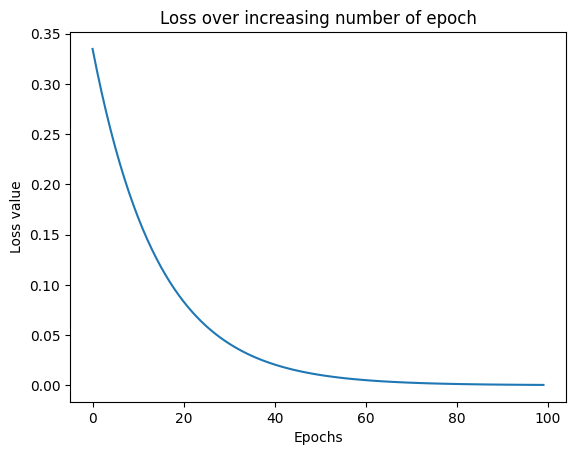

In [13]:
#1.导入包与定义数据集
import numpy as np
from copy import deepcopy
x=np.array([1,1])
y=np.array([0])
#2.初始化权重与偏置
W=[
    np.array([[-0.0053,0.3793],
         [-0.5820,-0.5204],
         [-0.2723,0.1896]],dtype=np.float32).T,
    np.array([-0.0140,0.5670,-0.0628],dtype=np.float32),
    np.array([[0.1528,-0.1745,-0.1135]],dtype=np.float32).T,
    np.array([-0.5516],dtype=np.float32)
]
#3.运行100个epoch
def feed_forward(inputs,outputs,weights):
  pre_hidden=np.dot(inputs,weights[0])+weights[1]
  hidden=1/(1+np.exp(-pre_hidden))
  pred_out=np.dot(hidden,weights[2])+weights[3]
  mean_squared_error=np.mean(np.square(pred_out-outputs))
  return mean_squared_error
def update_weights(inputs,outputs,weights,lr):
  original_weights=deepcopy(weights)
  tmp_weights=deepcopy(weights)
  updated_weights=deepcopy(weights)
  original_loss=feed_forward(inputs,outputs,weights)
  for i,layer in enumerate(original_weights):
    for index,weight in np.ndenumerate(layer):
      tmp_weights=deepcopy(weights)
      tmp_weights[i][index]+=0.0001
      _loss_plus=feed_forward(inputs,outputs,tmp_weights)
      grad=(_loss_plus-original_loss)/(0.0001)
      updated_weights[i][index]-=lr*grad
  return updated_weights,original_loss
losses=[]
for epoch in range(100):
  W,loss=update_weights(x,y,W,0.01)
  losses.append(loss)

import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(losses)
plt.title('Loss over increasing number of epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss value')


## 第二章 Pytorch基础

## 第三章 使用Pytorch构建深度神经网络

# 第二部分 物体分类与目标检测

## 第四章 卷积神经网络

### 使用Pytorch构建基于CNN的架构

In [ ]:
#1.导入相关代码库
import torch
from torch import nn
from torch.utils.data import TensorDataset,Dataset,DataLoader
from torch.optim import SGD,Adam
device='cuda' if torch.cuda.is_available() else 'cpu'
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#2.使用以下步骤创建数据集
X_train=torch.tensor([[[[1,2,3,4],[2,3,4,5],[5,6,7,8],[1,3,4,5]]],[[[-1,2,3,-4],[2,-3,4,5],[-5,6,-7,8],[-1,-3,-4,-5]]]]).to(device).float()
X_train/=8  #输入数据除以最大输入值8，将数据取值压缩到[-1,1] and 输入数据是(N,C,H,W)=(2,1,4,4),两个图片，一个通道，然后图像4x4
y_train=torch.tensor([0,1]).to(device).float()

#3.定义模型框架
def get_model():
  model=nn.Sequential(
      nn.Conv2d(in_channels=1,out_channels=16,kernel_size=3),
      nn.MaxPool2d(2),
      nn.ReLU(),
      nn.Flatten(),
      nn.Linear(1,1),
      nn.Sigmoid(),
  ).to(device)
  loss_fn=nn.BCELoss()
  optimizer=Adam(model.parameters(),lr=1e-3)
  return model,loss_fn,optimizer

##第五章 面向图像分类的迁移学习

##第六章 图像分类的实战技术

##第七章 目标检测基础

## 第八章 目标检测进阶

## 第九章 图像分割

## 第十章 目标检测与分割的应用

# 第三部分 图像处理

## 第十一章 自编码器与图像处理

## 第十二章 基于GAN的图像生产

## 第十三章 高级GAN图像处理

#第四部分 计算机视觉与其他技术

## 第十四章 使用小样本进行模型训练

## 第十五章 计算机视觉与NLP

## 第十六章 计算机视觉与强化学习

## 第十七章 模型的实际应用部署

##第十八章 使用OpenCV实用程序进行图像分析